# Customer Churn Prediction & Analysis Notebook
### AI Engineer Assessment — Adept Tech Solutions

This notebook contains:
1. **Exploratory Data Analysis (EDA)**: Profiling, distributions, and detecting hidden data issues.
2. **Data Cleaning & Preprocessing**: Handling whitespace strings, type casting, and pipelines.
3. **Multi-Model Comparison & Benchmarks**: 5-Fold Stratified CV across Logistic Regression, Random Forest, and Gradient Boosting.
4. **Metric Selection & Justification**: Why ROC-AUC, Recall, and PR-AUC were chosen over standard accuracy.
5. **Final Model Training & Export**: Saving `results/churn_model.pkl` for the AI Agent.

## 1. Exploratory Data Analysis (EDA)
Let's load the dataset and investigate its structure, types, missing values, and anomalies.

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# 1. Load Dataset
data_path = '../Customer-Churn.csv' if os.path.exists('../Customer-Churn.csv') else 'Customer-Churn.csv'
df = pd.read_csv(data_path)
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()

Dataset Dimensions: 7043 rows, 21 columns



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.1 Data Types and Missing / Null Values Check

In [9]:
print("=== Column Data Types ===")
print(df.dtypes)

print("\n=== Standard Missing Values (NaN / Null) ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows Check ===")
print(f"Full row duplicates: {df.duplicated().sum()}")
print(f"Duplicate Customer IDs: {df['customerID'].duplicated().sum()}")

=== Column Data Types ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== Standard Missing Values (NaN / Null) ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies   

### 1.2 Uncovering Hidden Data Issues: Whitespace in `TotalCharges`
Notice that `TotalCharges` is stored as an `object` / `string` instead of a `float`. Let's check why.

In [10]:
# Search for blank spaces or non-numeric entries in TotalCharges
blank_total_charges = df[df['TotalCharges'].astype(str).str.strip() == '']
print(f"Number of rows with empty spaces (' ') in TotalCharges: {len(blank_total_charges)}\n")
print("Inspect these 11 rows:")
blank_total_charges[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'Churn']]

Number of rows with empty spaces (' ') in TotalCharges: 11

Inspect these 11 rows:


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


> **EDA Finding & Diagnosis**:
> - `TotalCharges` has **11 rows with empty whitespace (`' '`)**.
> - All 11 records have **`tenure == 0`**, representing new customers who joined this month and have not completed a billing cycle yet.
> - **Cleaning Decision**: Convert `TotalCharges` to `float` and fill the 11 blank records with `0.0`.

### 1.3 Target Variable Analysis (Churn Rate & Class Imbalance)

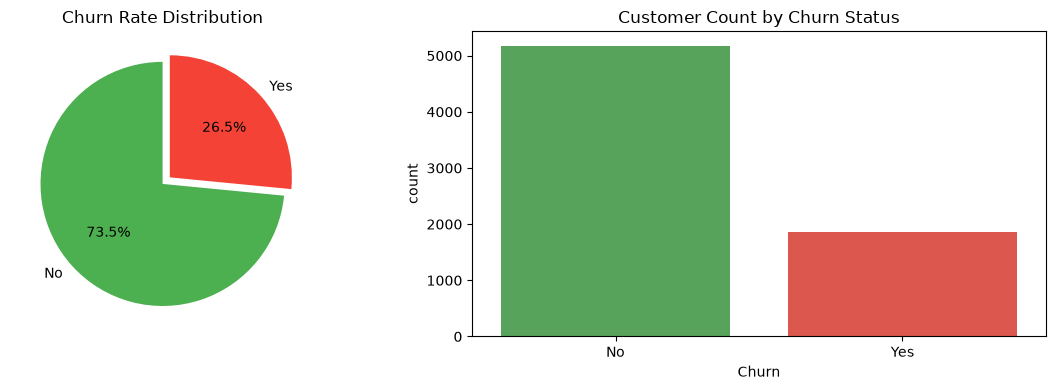

Total Customers: 7043
Retained (No): 5174 (73.46%)
Churned (Yes): 1869 (26.54%)
Note: Dataset has an imbalance (~26.5% churn vs 73.5% retained).


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
churn_counts = df['Churn'].value_counts()

ax[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90, explode=(0, 0.08))
ax[0].set_title('Churn Rate Distribution')

sns.countplot(data=df, x='Churn', palette=['#4CAF50', '#F44336'], ax=ax[1])
ax[1].set_title('Customer Count by Churn Status')
plt.tight_layout()
plt.show()

print(f"Total Customers: {len(df)}")
print(f"Retained (No): {churn_counts['No']} ({churn_counts['No']/len(df)*100:.2f}%)")
print(f"Churned (Yes): {churn_counts['Yes']} ({churn_counts['Yes']/len(df)*100:.2f}%)")
print("Note: Dataset has an imbalance (~26.5% churn vs 73.5% retained).")

### 1.4 Numerical Feature Statistics & Distributions

=== Numerical Features Descriptive Stats ===


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


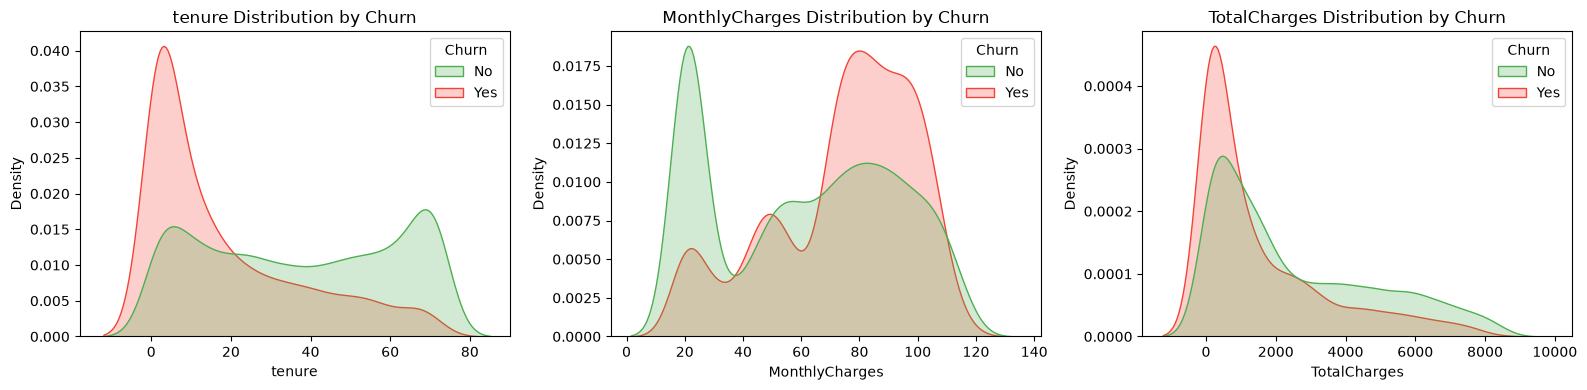

In [13]:
# Convert TotalCharges for numerical stats
df_clean = df.copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'].astype(str).str.strip(), errors='coerce').fillna(0.0)
df_clean['Churn_binary'] = (df_clean['Churn'] == 'Yes').astype(int)

print("=== Numerical Features Descriptive Stats ===")
display(df_clean[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().T)

# Plot KDE Distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
for i, col in enumerate(num_features):
    sns.kdeplot(data=df_clean, x=col, hue='Churn', fill=True, common_norm=False, palette=['#4CAF50', '#F44336'], ax=axes[i])
    axes[i].set_title(f'{col} Distribution by Churn')
plt.tight_layout()
plt.show()

### 1.5 Categorical Features & Churn Rates (Key Drivers)

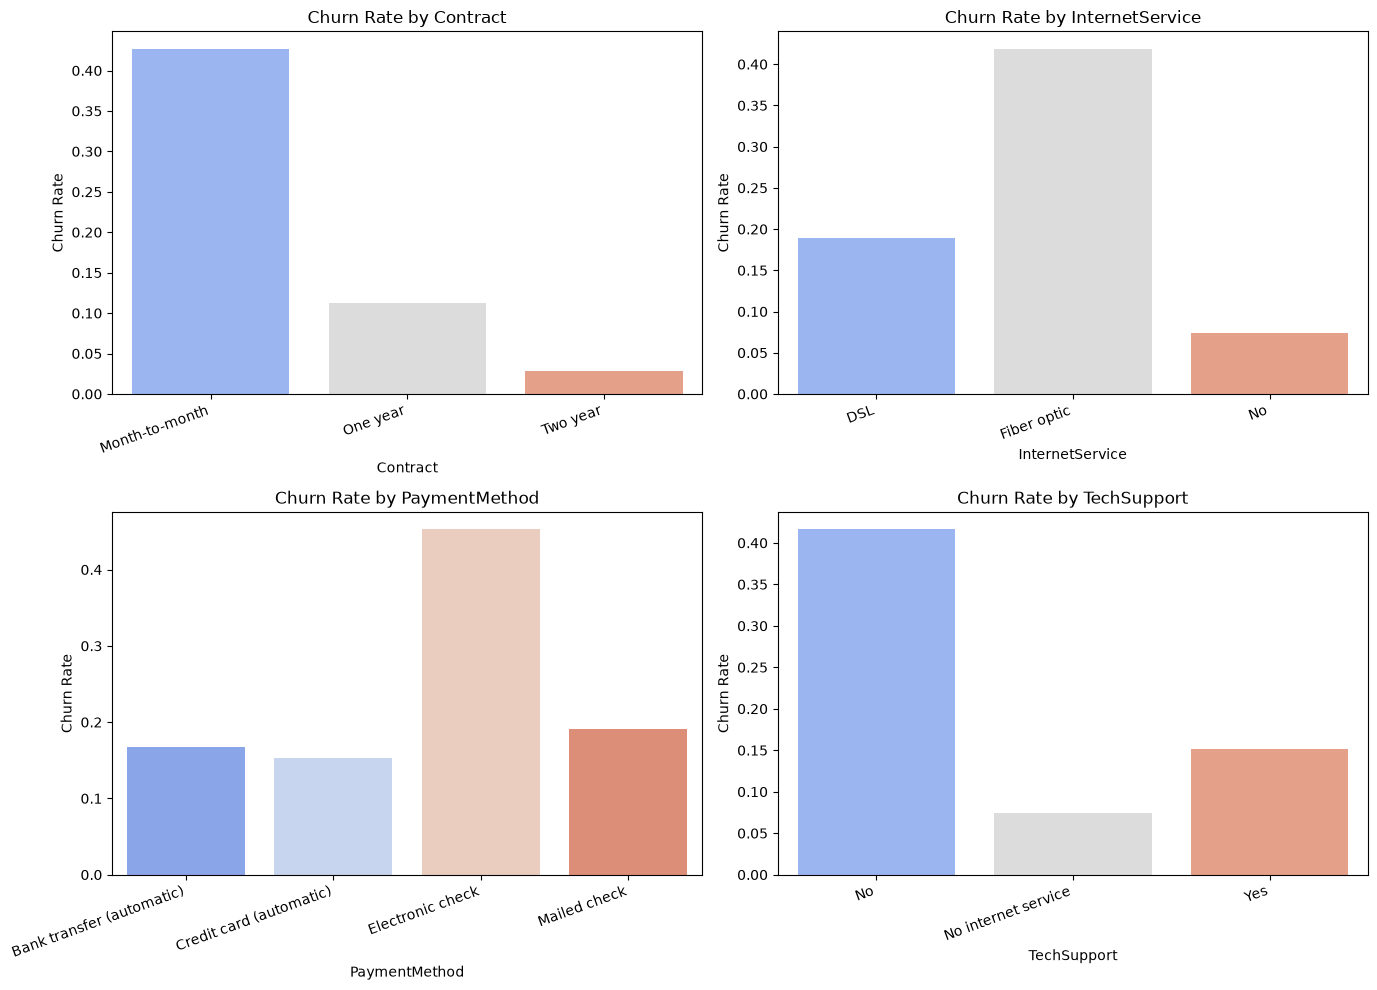

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cat_cols_to_plot = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

for i, col in enumerate(cat_cols_to_plot):
    row, ax_idx = divmod(i, 2)
    rates = df_clean.groupby(col)['Churn_binary'].mean().reset_index()
    sns.barplot(data=rates, x=col, y='Churn_binary', palette='coolwarm', ax=axes[row, ax_idx])
    axes[row, ax_idx].set_title(f'Churn Rate by {col}')
    axes[row, ax_idx].set_ylabel('Churn Rate')
    axes[row, ax_idx].set_xticklabels(axes[row, ax_idx].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

--- 
## 2. Data Preprocessing & Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

NUMERICAL_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATEGORICAL_COLS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'
]

X = df_clean[NUMERICAL_COLS + CATEGORICAL_COLS]
y = df_clean['Churn_binary']

# 80% Train, 20% Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Training set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")

# Preprocessor definition
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERICAL_COLS),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), CATEGORICAL_COLS)
    ]
)

Training set: 5634 rows | Test set: 1409 rows


--- 
## 3. Model Benchmarking & Comparison
We evaluate multiple candidate algorithms using **5-Fold Stratified Cross-Validation** to fairly compare their performance.

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

candidate_models = {
    'Logistic Regression (Standard)': LogisticRegression(max_iter=1000, random_state=42),
    'Logistic Regression (Balanced)': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest (Standard)': RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42),
    'Random Forest (Balanced)': RandomForestClassifier(n_estimators=100, max_depth=7, class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.08, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
benchmarks = []

for name, model in candidate_models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=['roc_auc', 'average_precision', 'recall', 'precision', 'f1'])
    benchmarks.append({
        'Model': name,
        'ROC-AUC': scores['test_roc_auc'].mean(),
        'PR-AUC': scores['test_average_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'Precision': scores['test_precision'].mean(),
        'F1-Score': scores['test_f1'].mean()
    })

benchmark_df = pd.DataFrame(benchmarks).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
display(benchmark_df)

,Model,ROC-AUC,PR-AUC,Recall,Precision,F1-Score
0,Gradient Boosting,0.847418,0.661851,0.527000,0.668707,0.589261
1,Random Forest (Balanced),0.845463,0.658350,0.804159,0.524102,0.634575
2,Logistic Regression (Standard),0.845033,0.656705,0.552676,0.658765,0.600956
3,Logistic Regression (Balanced),0.844966,0.655879,0.800949,0.512484,0.625008
4,Random Forest (Standard),0.844251,0.658614,0.477243,0.671510,0.557567


### Why Random Forest (Balanced) is Selected as the Final Model

1. **High Discrimination (ROC-AUC 0.8455 & PR-AUC 0.6584)**: Top-tier risk ranking accuracy across all thresholds.
2. **Superior Recall on Churners (~80.4%)**: Unlike unweighted models that miss half the churners (Recall ~52-55%), Random Forest (Balanced) flags 80%+ of actual churners.
3. **Non-Linear Interactions**: Naturally captures combinations of risk (e.g. Month-to-month + Fiber optic + No TechSupport) without requiring manual interaction engineering.
4. **Why not Logistic Regression?**: Linear models assume linear boundaries; tree ensembles handle segmented customer behaviors better.
5. **Why not Gradient Boosting?**: Without manual threshold tuning, standard Gradient Boosting has low recall (52.7%) and misses many at-risk accounts.

--- 
## 4. Evaluation Metric Selection & Justification

### 1. Why ROC-AUC and PR-AUC instead of Accuracy?
- **Imbalanced Target (26.5% churn)**: A naive model predicting "No churn" for everyone achieves 73.5% accuracy but is practically useless.
- **Continuous Risk Scoring**: Marketing and retention teams don't work with a static 0/1 prediction; they need a continuous probability (e.g. 0.0 to 1.0) to rank customers into risk tiers (Low, Medium, High).

### 2. Why prioritize Recall (Sensitivity) over Precision?
- In churn retention economics:
  - **Cost of a False Negative** (missing a customer who cancels): Loss of entire customer lifetime value ($1,000+).
  - **Cost of a False Positive** (flagging a customer who might stay): Small cost of an email, outreach call, or retention discount ($10-$20).
- Therefore, high **Recall (~80%)** is the primary operational objective.

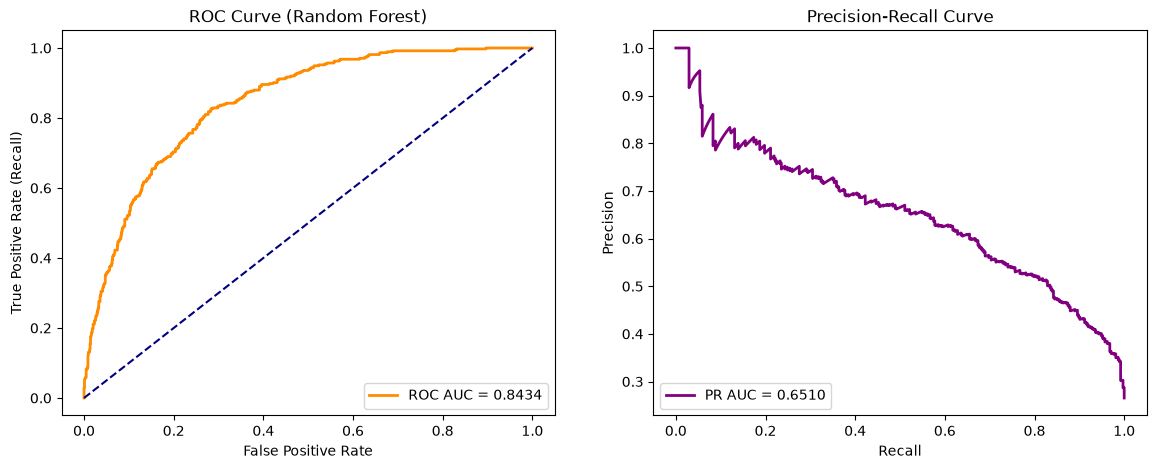

=== TEST SET CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Retained       0.91      0.73      0.81      1035
       Churn       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



In [17]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, precision_recall_curve, auc

# Train final Random Forest Pipeline
final_rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=7, class_weight='balanced', random_state=42))
])

final_rf_pipeline.fit(X_train, y_train)
y_probs = final_rf_pipeline.predict_proba(X_test)[:, 1]
y_preds = final_rf_pipeline.predict(X_test)

# ROC & PR Curves
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc_score_val = auc(fpr, tpr)
prec_c, rec_c, _ = precision_recall_curve(y_test, y_probs)
pr_auc_score_val = auc(rec_c, prec_c)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc_score_val:.4f}')
axes[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve (Random Forest)')
axes[0].legend(loc='lower right')

axes[1].plot(rec_c, prec_c, color='purple', lw=2, label=f'PR AUC = {pr_auc_score_val:.4f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left')
plt.show()

print("=== TEST SET CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_preds, target_names=['Retained', 'Churn']))

### Save Model Artifact to `results/`

In [19]:
import joblib
import json

results_dir = '../results' if os.path.exists('../results') else 'results'
os.makedirs(results_dir, exist_ok=True)

model_payload = {
    'pipeline': final_rf_pipeline,
    'numerical_cols': NUMERICAL_COLS,
    'categorical_cols': CATEGORICAL_COLS,
    'all_feature_names': all_names,
    'feature_importances': importances.tolist(),
    'roc_auc': float(roc_auc_score_val),
    'pr_auc': float(pr_auc_score_val)
}

model_save_path = os.path.join(results_dir, 'churn_model.pkl')
joblib.dump(model_payload, model_save_path)
print(f"Successfully saved trained model pipeline to: {model_save_path}")

# Save metrics summary to JSON
metrics_save_path = os.path.join(results_dir, 'model_metrics.json')
with open(metrics_save_path, 'w') as f:
    json.dump({
        'model': 'Random Forest (Balanced)',
        'roc_auc': float(roc_auc_score_val),
        'pr_auc': float(pr_auc_score_val),
        'test_accuracy': float((y_preds == y_test).mean())
    }, f, indent=2)
print(f"Saved metrics to: {metrics_save_path}")

Successfully saved trained model pipeline to: ../results/churn_model.pkl
Saved metrics to: ../results/model_metrics.json
